In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## NOTE for Maddie

For saving, the mask files have been going to two locations.


#### I.  HOLYLABS (permanent):
    
    /n/holylabs/gershman_lab/Users/zkelso/planaria_masks/
    
    
#### II. NETSCRATCH (scratchpad while I was doing QC): 
    
    /n/netscratch/gershman_lab/Lab/zkelso/Masks/

The files have been following this naming convention:

    2025_10_14_10_25_19_trial_1_TC_regions_377_455_595_1388_fullvideo_binary_masks.npz
    
This is **[timestamp_ID]__[regions]_fullvideo_binary_masks.npz**. Some files have an additional timestamp at the end which represents when the mask was made. This is superfluous info that I added just to help me compare variants of thresholds and the like -- no need to retain that info. 

The reason fullvideo was added because it was easier to process an entire video's mask into several trials than was to process multiple videos for the same session. 



#### Current block layout:
Simple Session-List Notebook Structure

CELL 1: Imports
Import all required packages: os, numpy, torch, pandas, matplotlib, PIL, cv2, io, imageio, and pathlib.Path.

CELL 2: Device Setup
Detect and configure the compute device (CUDA/MPS/CPU). Set up torch autocast and float32 settings if using CUDA.

CELL 3: Session Discovery & File Checking
- USER EDIT SECTION: Define sessions_to_process list (e.g., ['2025_09_19_10_27_01_trial_1', '2024_12_11_18_51_54_trial_1'])
- Define paths: holylabs_base, masks_base, video_folders_base
- Loop through each session in the list
- For each session: find the session folder, search for *_fullvideo subfolders, check JPG count (>100), check if mask NPZ file exists
- Populate two lists: done_session_worms (videos with existing masks) and to_process (videos needing masks)
- Print summary of findings

CELL 4: Function Definitions
Define all helper functions: show_mask(), show_points(), show_box(), pick_point(), get_points_and_labels(), get_boxes(), dynamically_add_points(), display_new_frames(), make_a_gif()

CELL 5: VideoSplicer Class
Define the VideoSplicer class with interactive widget for marking splice points in videos (slider, button, frame display)

CELL 6: Initialize SAM2 Predictor
Load SAM2 model checkpoint and configuration. Initialize the predictor object that will be used for segmentation.

CELL 7: Load Video & Display Widget
Check if to_process is empty. If videos exist, load the first video from to_process, scan frame names, display first frame, create and display VideoSplicer widget for marking chunks.

CELL 8: Process Current Video
Get chunks from widget. Loop through each chunk: initialize predictor state, show box selection dialogs for multiple frames, propagate segmentation through chunk, reset state. Display visualization. Allow dynamic point refinement. Increment video counter and prompt to run Cell 7 again for next video.

# Video segmentation with SAM 2

This notebook is based off of video_predictor_example. To deal with long periods of occlusion, we splice the session video into sections of un-occluded and occluded, and separately propagate labels through each one. We then stitch the video back together at the end to get a full timeseries of the masked worm. 

This notebook has been further modified to take a list of session names (timestamp folder name containing bin file). The code loops through each folder entity (widget video 1 --> process video 1 --> widget video 2 --> process video 2 --> etc.) until the list has been iterated through.

## Environment Set-up

In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pdb
import torch
import io
import imageio
from pathlib import Path
import math

print("Packages loaded. Proceed.")

Packages loaded. Proceed.


In [3]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


# For a given session, find the videos/jpgs that don't yet have QC'd masks.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# SESSION LIST - Edit this to process multiple sessions
# ═══════════════════════════════════════════════════════════════════════════

# sessions_to_process = ["2025_10_17_14_18_23_trial_1_TC"]   # Takes a list of strings corresponding to session timestamp IDs

sessions_to_process =[
#'2025_10_14_10_25_19_trial_1_TC',
'2025_10_14_10_35_03_trial_1_TC',   
'2025_10_14_14_13_15_trial_1_TC',
'2025_10_15_10_09_28_trial_1_TC',
'2025_10_15_14_16_21_trial_1_TC',
'2025_10_16_09_59_15_trial_1_TC',
'2025_10_16_14_12_17_trial_1_TC',
'2025_10_17_10_05_03_trial_1_TC',
'2025_10_17_14_18_23_trial_1_TC',]

# ═══════════════════════════════════════════════════════════════════════════
# Path setup
# ═══════════════════════════════════════════════════════════════════════════

holylabs_base = "/n/holylabs/gershman_lab/Users/zkelso/Raw_data/"
masks_base = "/n/holylabs/gershman_lab/Users/zkelso/Masks/"
gifs_base = "/n/netscratch/gershman_lab/Lab/zkelso/GIFs/"
boxes_base = "/n/holylabs/gershman_lab/Users/zkelso/DLC_Projects/WormTracking/labeled_data/"
# Choose where to look for video folders (uncomment one):
video_folders_base = "/n/netscratch/gershman_lab/Lab/zkelso/temporary_jpgs/unlabeled-data"
video_split_csv = "/n/holylabs/gershman_lab/Lab/zkelso/video_splits.csv"

# ═══════════════════════════════════════════════════════════════════════════
# Find and check videos for all sessions
# ═══════════════════════════════════════════════════════════════════════════

done_session_worms = []
to_process = []

for session in sessions_to_process:
    print(f"\n{'='*80}")
    print(f"Checking session: {session}")
    print(f"{'='*80}")
    
    # Path to this session's folder
    session_folder = Path(video_folders_base) / session
    
    # Check if session folder exists
    if not session_folder.exists():
        print(f"WARNING: Session folder not found at {session_folder}")
        continue
    
    # Find all video folders inside this session (ending with _fullvideo)
    video_folders = list(session_folder.glob("*_fullvideo"))
    
    if video_folders:
        print(f"Found {len(video_folders)} video folder(s):")
        for folder in video_folders:
            print(f"  - {folder.name}")
    else:
        print(f"No video folders (*_fullvideo) found in {session}")
        continue
    
    # Check each video folder
    for video_folder in video_folders:
        print(f"\nChecking: {video_folder.name}")
        
        # Check 1: Does it have JPG files?
        jpg_count = sum(1 for f in video_folder.iterdir() 
                       if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg"])
        has_jpgs = jpg_count > 100
        
        if has_jpgs:
            print(f"  [OK] JPG files: {jpg_count} frames")
        else:
            print(f"  [X] JPG files: Only {jpg_count} frames (need >100)")
            continue  # Skip this video
        
        # Check 2: Does it already have a mask file?
        npz_filename1 = f"{video_folder.name}_points_binary_masks.npz"
        npz_filename2 = f"{video_folder.name}_boxes_binary_masks.npz"
        npz_path1 = Path(masks_base) / npz_filename1; npz_path2 = Path(masks_base) / npz_filename2
        
        if npz_path1.exists():
            print(f"  [OK] Mask exists: {npz_filename1}")
            done_session_worms.append(str(npz_path1))
        elif npz_path2.exists():
            print(f"  [OK] Mask exists: {npz_filename2}")
            done_session_worms.append(str(npz_path2))
        else:
            print(f"  [PROCESS] Mask not found: {npz_filename1}")
            to_process.append(str(video_folder))  # Add full path to video folder

# ═══════════════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"\nProcessed {len(sessions_to_process)} session(s)")
print(f"Total videos found: {len(done_session_worms) + len(to_process)}")
print(f"  Already have masks: {len(done_session_worms)}")
print(f"  Need processing: {len(to_process)}")

if to_process:
    print(f"\nVideos to process:")
    for video_path in to_process:
        print(f"  - [ ] {Path(video_path).name}")


Checking session: 2025_10_14_10_35_03_trial_1_TC
Found 6 video folder(s):
  - 2025_10_14_10_35_03_trial_1_TC_regions_1111_388_1355_1335_fullvideo
  - 2025_10_14_10_35_03_trial_1_TC_regions_1350_394_1568_1338_fullvideo
  - 2025_10_14_10_35_03_trial_1_TC_regions_153_425_395_1367_fullvideo
  - 2025_10_14_10_35_03_trial_1_TC_regions_390_425_624_1364_fullvideo
  - 2025_10_14_10_35_03_trial_1_TC_regions_635_407_866_1364_fullvideo
  - 2025_10_14_10_35_03_trial_1_TC_regions_866_391_1105_1370_fullvideo

Checking: 2025_10_14_10_35_03_trial_1_TC_regions_1111_388_1355_1335_fullvideo
  [OK] JPG files: 1799 frames
  [PROCESS] Mask not found: 2025_10_14_10_35_03_trial_1_TC_regions_1111_388_1355_1335_fullvideo_points_binary_masks.npz

Checking: 2025_10_14_10_35_03_trial_1_TC_regions_1350_394_1568_1338_fullvideo
  [OK] JPG files: 1799 frames
  [PROCESS] Mask not found: 2025_10_14_10_35_03_trial_1_TC_regions_1350_394_1568_1338_fullvideo_points_binary_masks.npz

Checking: 2025_10_14_10_35_03_trial_1_TC_

PROCESSING: 2025_10_14_10_35_03_trial_1_TC_regions_1111_388_1355_1335_fullvideo


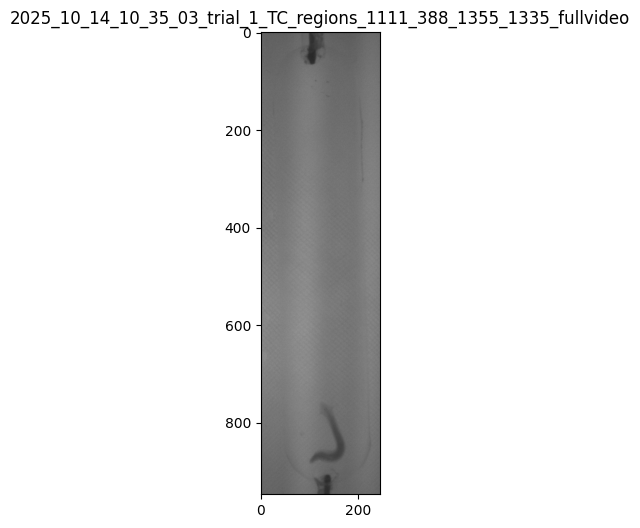

In [5]:
# ======= CONFIGURE WHICH VIDEO TO PROCESS HERE ===============================

for i in to_process:
    npz_path = masks_base + str(i.split('/')[-1:][0])+'_binary_masks.npz'
    
    if os.path.exists(npz_path):
        to_process.remove(npz_path)
    else:
        CURRENT_VIDEO = str(i.split('/')[-1:][0])
        print("PROCESSING: "+ CURRENT_VIDEO)
        break

make_gif = True



# ======== NO NEED TO EDIT BELOW THIS LINE ===============================================================================

# Split regions out of video name to use in file path reconstruction
current_video_folder = CURRENT_VIDEO.split("_regions")[0]

# Create strings to reconstruct video pathway
video_dir = f"{video_folders_base}/{current_video_folder}/{CURRENT_VIDEO}"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
#2025_10_14_10_25_19_trial_1_TC_regions_1072_463
# take a look the first video frame to make sure it's kind of what you want
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"{CURRENT_VIDEO}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

# Define functions

In [6]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

# Mouse callback remains the same
def pick_point(event, x, y, flags, param):
    curr_img, curr_coords, w_name = param
    event_counter=0
    if event == cv2.EVENT_LBUTTONDOWN:
        curr_coords.append([x, y])
        if event_counter>2:
            cv2.circle(curr_img, (x, y), 7, (0, 0, 255), -1)
        elif event_counter<3:
            cv2.circle(curr_img, (x, y), 7, (0, 255, 0), -1)
        else:
            print("Click events exceeded 4. Redo")
            return
               
        event_counter+=1
        cv2.putText(curr_img, str(len(curr_coords)), (x + 10, y + 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.imshow(w_name, curr_img)

def get_points_and_labels(frame,video_dir,frame_names,start):
            
    img_path = os.path.join(video_dir, frame_names[frame])
    print(f"Loading: {frame_names[frame]}")
    
    image = cv2.imread(img_path)
    if image is None:
        print(f"Failed to load {img_path}")
        return
        
    display_img = image.copy()
    clicked_coords = []
    
    window_name = f"Frame {frame_names[frame]} - Add two points, subtract two points --> Enter"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1600, 1000)
    
    # Set callback with the specific display_img for THIS frame
    cv2.setMouseCallback(window_name, pick_point, [display_img, clicked_coords, window_name])  
    
    # Show the NEW image
    cv2.imshow(window_name, display_img)

    # Wait for keypress
    cv2.waitKey(0)
    
    # Clean up THIS specific window
    cv2.destroyWindow(window_name)
    cv2.waitKey(1) 

    points = np.array(clicked_coords, dtype=np.float32)

    labels = np.array([1,1,0,0], dtype=np.int32)

    return points,labels

def update_frame_data(file_path, frame_idx, coordinates):
    # 1. Check if file exists; if not, create an empty dict and save it
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Creating new database...")
        data = {}
        np.save(file_path, data) 
    
    # 2. Load the existing dictionary
    # we use .item() to pull the dictionary out of the numpy wrapper
    data = np.load(file_path, allow_pickle=True).item()

    # 3. Check if frame is missing and update
    if frame_idx not in data:
        data[frame_idx] = coordinates
        # 4. Save back to disk
        np.save(file_path, data)
        print(f"Frame {frame_idx} successfully saved to {file_path}.")
    else:
        print(f"Frame {frame_idx} is already in the file. No changes made.")


def get_boxes(frame, video_dir, frame_names, start, all_labeled_frames_path):
    img_path = os.path.join(video_dir, frame_names[frame])
    image = cv2.imread(img_path)
    if image is None: 
        print(f"Error: Could not load {img_path}")
        return None, None, None

    window_name = f"Frame {frame} | 1. GREEN: OBJECT -> ENTER | 2. RED: BACKGROUND -> ENTER"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1600, 1000)

    # --- STEP 1: Positive Box (The Object) ---
    # Drag green box, then press ENTER or SPACE
    roi_pos = cv2.selectROI(window_name, image, showCrosshair=True)
    pos_box = np.array([roi_pos[0], roi_pos[1], roi_pos[0] + roi_pos[2], roi_pos[1] + roi_pos[3]], dtype=np.float32)

    # Draw the green box on a copy to show the user what they already selected
    display_img = image.copy()
    cv2.rectangle(display_img, (roi_pos[0], roi_pos[1]), 
                  (roi_pos[0]+roi_pos[2], roi_pos[1]+roi_pos[3]), (0, 255, 0), 3)

    # --- STEP 2: Negative Box (Background exclusion) ---
    # Drag red box, then press ENTER or SPACE. If no background box is needed, just press ENTER.
    roi_neg = cv2.selectROI(window_name, display_img, showCrosshair=True)
    
    # --- STEP 3: Convert Negative Box to Grid ---
    neg_points = []
    if roi_neg[2] > 0 and roi_neg[3] > 0:
        x_coords = np.linspace(roi_neg[0], roi_neg[0] + roi_neg[2], 3)
        y_coords = np.linspace(roi_neg[1], roi_neg[1] + roi_neg[3], 3)
        for x in x_coords:
            for y in y_coords:
                neg_points.append([x, y])

    cv2.destroyWindow(window_name)
    cv2.waitKey(1)

    # Convert to SAM 2 Format
    # If no negative box was drawn, we return an empty array of the correct shape
    if len(neg_points) > 0:
        final_points = np.array(neg_points, dtype=np.float32)
        final_labels = np.zeros(len(neg_points), dtype=np.int32)
    else:
        final_points = np.empty((0, 2), dtype=np.float32)
        final_labels = np.empty((0,), dtype=np.int32)

    # --- STEP 4: Persistent Save ---
    frame_data = {
        "points": final_points,
        "labels": final_labels,
        "box": pos_box
    }

    # Use the path passed in from the main loop
    update_frame_data(all_labeled_frames_path, frame, frame_data)

    return final_points, final_labels, pos_box


def dynamically_add_points(frame_list, prop_len, video_dir, frame_names, predictor, inference_state, start_frame, end_frame, mode="add"):
            
    for frame in frame_list:
        img_path = os.path.join(video_dir, frame_names[frame])
        print(f"Loading: {frame_names[frame]} (Frame {frame})")
        
        image = cv2.imread(img_path)
        if image is None:
            print(f"Failed to load {img_path}")
            return
            
        display_img = image.copy()
        clicked_coords = []
        
        window_name = f"Frame {frame} - Add two points, subtract two points --> Enter"
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
        cv2.resizeWindow(window_name, 1600, 1000)
        
        # Set callback with the specific display_img for THIS frame
        cv2.setMouseCallback(window_name, pick_point, [display_img, clicked_coords, window_name, mode])  
        
        # Show the NEW image
        cv2.imshow(window_name, display_img)
    
        # Wait for keypress
        cv2.waitKey(0)
        
        # Clean up THIS specific window
        cv2.destroyWindow(window_name)
        cv2.waitKey(1) 
    
        points = np.array(clicked_coords, dtype=np.float32)

        labels = np.array([1,1,0,0], dtype=np.int32)

        if clicked_coords == []:
            return
        else:
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=frame,
                obj_id=ann_obj_id,
                points=points,
                labels=labels,
            )
        
            # show the results on the current (interacted) frame
            plt.figure(figsize=(9, 6))
            plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame])))
            show_points(points, labels, plt.gca())
            show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

    # Outside the original frames loop, run propagation throughout the video and collect the results in a dict
    video_segments = {}  # video_segments contains the per-frame segmentation results
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
        inference_state, 
        start_frame_idx=start_frame, # Force it to start from the beginning
        max_frame_num_to_track=end_frame-start_frame+1, 
        reverse=False
    ):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
        
    return video_segments


def display_new_frames(vis_frame_stride,start_frame,end_frame,video_dir,frame_names,video_segments):
    # visualize the segmentation results every few frames
    #plt.close("all")
    for out_frame_idx in range(start_frame,end_frame, vis_frame_stride):
        plt.figure(figsize=(6, 4))
        plt.title(f"frame {out_frame_idx}")
        plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
        for out_obj_id, out_mask in video_segments[out_frame_idx].items():
            show_mask(out_mask, plt.gca(), obj_id=out_obj_id)


def make_a_gif(frame_names,video_dir,video_segments,output_path):

    gif_frames = []
    vis_frame_stride = 1

    # Optional: define which frames to process. 
    # Using range(0, len(frame_names)) might take a long time if the video is long.
    for out_frame_idx in range(1, len(frame_names), vis_frame_stride):
        # Create a wider figure for two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
        
        # Load the base image once
        img_path = os.path.join(video_dir, frame_names[out_frame_idx])
        raw_image = Image.open(img_path)
        
        # --- Left Plot: Original Image ---
        ax1.imshow(raw_image)
        ax1.set_title(f"Original Frame {out_frame_idx}")
        ax1.axis('off') # Hide tick marks for a cleaner look
        
        # --- Right Plot: Image + Segmentation ---
        ax2.imshow(raw_image)
        #for out_obj_id, out_mask in enumerate(video_segments[out_frame_idx].items():
        for out_mask in video_segments[out_frame_idx]:
            show_mask(out_mask, ax2, obj_id=1)
        ax2.set_title(f"Segmentation {out_frame_idx}")
        ax2.axis('off')
        
        # Standardize layout
        plt.tight_layout() 
        
        # Save to buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png') 
        buf.seek(0)
        
        # Read back and store
        img = imageio.v2.imread(buf)
        gif_frames.append(img)
        
        # Clean up memory
        plt.close(fig)
    
    # Save the side-by-side GIF
    imageio.mimsave(output_path+'_GIF.gif', gif_frames, fps=13, loop=0)
    
    print(f"Side-by-side GIF saved successfully at: {output_path}")

# Load SAM2 video predictor

In [7]:
from sam2.build_sam import build_sam2_video_predictor

# Maddie path vs. Zach path
sam2_checkpoint = "/n/holylabs/gershman_lab/Users/zkms/sam_checkpoints/sam2.1_hiera_large.pt"


model_cfg = "//n/holylabs/gershman_lab/Users/zkms/sam_checkpoints/sam2.1_hiera_l.yaml"
#model_cfg = "/configs/sam2.1/sam2.1_hiera_l.yaml" # This only works if current working directory is sam2 in remote desktop's home##


# Initialize one predictor
predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

print("Loaded video predictor.")

Loaded video predictor.


# Begin iterative refinement training loop. 

### Here you can use boxes or points, depending on which one works better.

In [8]:
use_prior_labels = True
use_boxes = False

In [9]:
if use_boxes: 
    all_video_segments = {}
    all_labeled_frames_path = boxes_base + CURRENT_VIDEO + '_SAM_boxes.npy'

    # --- 1. Load ALL existing coordinates from the file ---
    if os.path.exists(all_labeled_frames_path):
        existing_data = np.load(all_labeled_frames_path, allow_pickle=True).item()
        labeled_indices = sorted(list(existing_data.keys()))
        print(f"✅ Found {len(labeled_indices)} previously labeled frames:")
        print(f"Frames: {labeled_indices}")
        if not use_prior_labels:
            print("Not using prior labels!")
            existing_data = {}
    else:
        print("No prior labels exist")
        existing_data = {}
        labeled_indices = []
    
    # --- 2. Select frames ---
    num_new_frames = 15
    total_video_range = range(1, 1799)
    video_start = total_video_range[0]; video_end = total_video_range[-1]
    
    if not labeled_indices:
        # If starting from scratch, just pick 15 evenly across the whole video, MUST include the first frame.
        new_frames_to_label = np.linspace(video_start, video_end - 1, num_new_frames, dtype=int).tolist()
    else:
        # Include boundaries to find gaps at the very beginning or very end
        temp_indices = sorted(list(set([video_start] + labeled_indices + [video_end])))
        
        # Calculate all possible frames that aren't labeled yet
        unlabeled_pool = [f for f in range(video_start, video_end + 1) if f not in existing_data]
        
        if len(unlabeled_pool) <= num_new_frames:
            new_frames_to_label = unlabeled_pool
        else:
            # We sample 15 frames from the unlabeled pool using a stride
            # This ensures they are evenly distributed among the "empty" territory
            stride = len(unlabeled_pool) / num_new_frames
            new_frames_to_label = [unlabeled_pool[int(i * stride)] for i in range(num_new_frames)]
    
    print(f"New frames to label: {new_frames_to_label}")
    
    # --- 3. Start the Processing Loop ---
    current_state = predictor.init_state(video_path=video_dir)
    
    # A. First, add NEW labels via the UI
    for frame in new_frames_to_label:
        # get_boxes will internally call update_frame_data and save to the .npy
        pts, lbls, box = get_boxes(frame, video_dir, frame_names, video_start, all_labeled_frames_path)
        
        # We also add it to our local existing_data dict so we can use it in step B
        existing_data[frame] = {"points": pts, "labels": lbls, "box": box}
    
    # B. Seed the predictor with ALL labeled frames (the ones we just did + all previous)
    print(f"Seeding predictor with {len(existing_data)} total anchor frames...")
    for frame_idx, data in existing_data.items():
        predictor.add_new_points_or_box(
            inference_state=current_state,
            frame_idx=frame_idx,
            obj_id=1,
            points=data['points'],
            labels=data['labels'],
            box=data['box']
        )
    
    # C. Propagate using the collective memory
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
        current_state, 
        start_frame_idx=video_start,
        max_frame_num_to_track=(video_end - video_start + 1)
    ):
        all_video_segments[out_frame_idx] = (out_mask_logits[0] > 0.0).cpu().numpy()
    
    predictor.reset_state(current_state)
    del current_state
else:
    print("Skipped cell, run using points")

Skipped cell, run using points


# Try with points instead.

In [ ]:
if not use_boxes:
    # --- Configuration ---
    first_frame_idx = 0  # The start of your video
    all_points_path = boxes_base + CURRENT_VIDEO + '_SAM_points.npy'
    all_video_segments = {} # To store the results
    
    # 1. Initialize the predictor state
    inference_state = predictor.init_state(video_path=video_dir)
    
    # 2. Get points from the UI for the first frame
    # We use your existing get_points_and_labels function
    points, labels = get_points_and_labels(first_frame_idx, video_dir, frame_names, 0)
    
    # 3. Format and Save to the .npy file (Dictionary format)
    # We set 'box' to None or an empty list so it matches the dictionary structure
    frame_bundle = {
        "points": points,
        "labels": labels,
        "box": None  # No box for this specific prompt
    }
    
    update_frame_data(all_points_path, first_frame_idx, frame_bundle)
    
    # Safety check: Match labels length to the number of points actually clicked
    if len(points) != len(labels):
        print(f"Adjusting labels: you clicked {len(points)} points.")
        # Create 1s for the first few and 0s for the rest, or just all 1s if only 1-2 points
        labels = np.ones(len(points), dtype=np.int32) 
        if len(points) > 2:
            labels[2:] = 0 # Assume 3rd and 4th clicks are negative labels
    
    # 3. Add the points to the predictor
    predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=first_frame_idx,
        obj_id=1,
        points=points,
        labels=labels,
    )
    
    # 4. Propagate through the entire video
    print("Propagating through the full video... this may take a moment.")
    for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
        # Store the mask (thresholded at 0.0)
        all_video_segments[out_frame_idx] = (out_mask_logits[0] > 0.0).cpu().numpy()
    
    # 5. Clean up
    # predictor.reset_state(inference_state) # Uncomment if you want to clear memory immediately
    print(f"Propagation complete. {len(all_video_segments)} frames processed.")
else:
    print("Skipped cell, box labels were used")

frame loading (JPEG): 100%|█████████████████| 1799/1799 [00:42<00:00, 41.99it/s]


Loading: 00000.jpeg


# Visualize Propagated Frames & Make GIF

In [ ]:
start_frame = 1
end_frame = 60
vis_stride = 1 # Change to 2 or 5 to see fewer, larger frames
frames_to_show = range(start_frame, end_frame + 1, vis_stride)

# Calculate grid dimensions
num_frames = len(frames_to_show)
cols = 5 
rows = math.ceil(num_frames / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, frame_idx in enumerate(frames_to_show):
    # 1. Load image
    img_path = os.path.join(video_dir, frame_names[frame_idx])
    img = Image.open(img_path)
    
    ax = axes[i]
    ax.imshow(img)
    
    # 2. Overlay Mask if it exists in your dictionary
    if frame_idx in all_video_segments:
        mask = all_video_segments[frame_idx]
        # show_mask is a utility function usually provided in the SAM 2 notebook
        show_mask(mask, ax, obj_id=1)
    
    ax.set_title(f"Frame {frame_idx}")
    ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Save a gif if specified
if make_gif == True:
    if not use_boxes:
        output_path = gifs_base + CURRENT_VIDEO + '_points'
    else: 
        output_path = gifs_base + CURRENT_VIDEO + '_boxes'
    make_a_gif(frame_names,video_dir,all_video_segments,output_path)


# Save Masks

In [ ]:
# 1. Sort the frames to ensure chronological order
sorted_frames = sorted(all_video_segments.keys())

# 2. Stack them into a single 4D array: (Frames, Channels, Height, Width)
# Current shape is (1, 936, 260), so result will be (N, 1, 936, 260)
mask_stack = np.stack([all_video_segments[f] for f in sorted_frames])

# 3. Save as a compressed file
if not use_boxes:
    out_path =  masks_base + CURRENT_VIDEO + '_points_binary_masks.npz'
else:
    out_path =  masks_base + CURRENT_VIDEO + '_boxes_binary_masks.npz'
np.savez_compressed(out_path, masks=mask_stack)